<a href="https://colab.research.google.com/github/ExTc-aShiSh/Introduction-to-AI/blob/main/Tower_of_Hanoi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

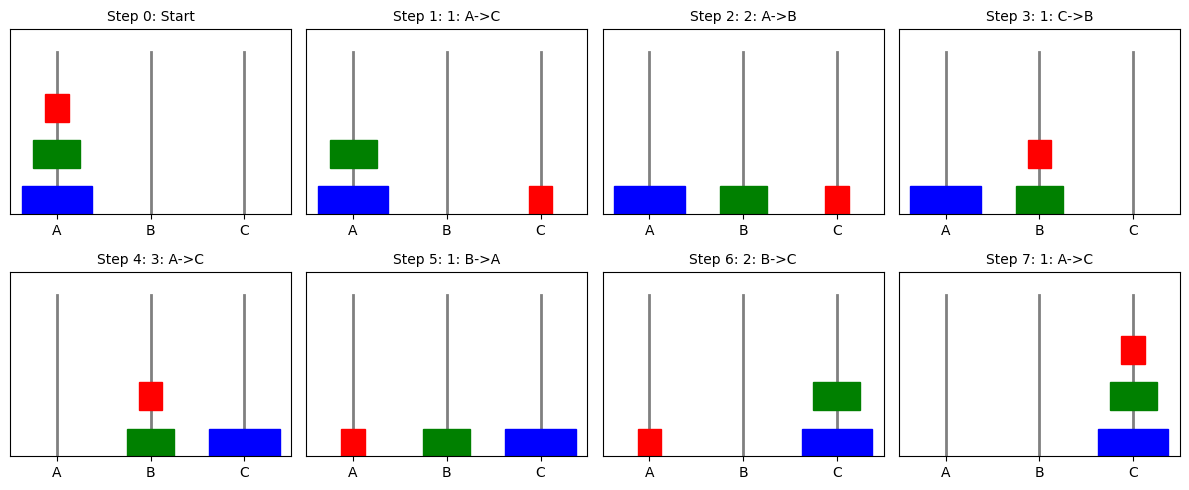

In [ ]:
import matplotlib.pyplot as plt
import copy

def solve_hanoi_list(n, source, destination, auxiliary, state, history):
    if n == 1:
        disk = state[source].pop()
        state[destination].append(disk)
        history.append({'state': copy.deepcopy(state), 'move': f"1: {['A','B','C'][source]}->{['A','B','C'][destination]}"})
        return

    solve_hanoi_list(n - 1, source, auxiliary, destination, state, history)
    disk = state[source].pop()
    state[destination].append(disk)
    history.append({'state': copy.deepcopy(state), 'move': f"{n}: {['A','B','C'][source]}->{['A','B','C'][destination]}"})
    solve_hanoi_list(n - 1, auxiliary, destination, source, state, history)

def visualize_matrix(history):
    num_steps = len(history)
    cols = 4
    rows = (num_steps + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(12, 2.5 * rows))
    axes = axes.flatten()

    colors = ['red', 'green', 'blue']

    for i in range(len(axes)):
        ax = axes[i]
        if i < num_steps:
            step_data = history[i]
            state = step_data['state']
            ax.set_title(f"Step {i}: {step_data['move']}", fontsize=10)
            ax.set_xlim(-0.5, 2.5)
            ax.set_ylim(0, 4)
            ax.set_xticks([0, 1, 2])
            ax.set_xticklabels(['A', 'B', 'C'])
            ax.set_yticks([])

            # Draw Rods
            for rod_idx in range(3):
                ax.plot([rod_idx, rod_idx], [0, 3.5], color='gray', lw=2, zorder=1)

                # Draw Disks
                for height, disk_size in enumerate(state[rod_idx]):
                    width = disk_size * 0.25
                    rect = plt.Rectangle((rod_idx - width/2, height), width, 0.6,
                                         color=colors[disk_size-1], zorder=2)
                    ax.add_patch(rect)
        else:
            ax.axis('off')

    plt.tight_layout()
    plt.show()

# Execution
num_disks = 3
initial_state = [[3, 2, 1], [], []]
history = [{'state': copy.deepcopy(initial_state), 'move': 'Start'}]
solve_hanoi_list(num_disks, 0, 2, 1, initial_state, history)
visualize_matrix(history)